> **⚠️ SUPERSEDED (2026-07-08).** This raw / single-tail view keeps the frequency / founder-projection confound and is **not** evidence of SV climate purging. The de-trended `s_distribution_by_site.ipynb` is authoritative, and after the full-panel Kf_w / `--unit chrom` regeneration the SV excess-vs-baseline is null there (median +0.0011, 15/31 sites, sign test n.s.).

# Distribution of selection coefficient s per site — SNP / indel / SV (common MAF only)

Per site, the histogram of the **plot-replicate selection coefficient** s (mean over the site's
~10–12 replicate plots of the logit(p)-on-generation slope), overlaid by variant class:
**SNP (grey), small indel ≤50 bp (blue), SV >50 bp (orange)**. Densities (area = 1) so the classes
are comparable despite very different counts. Dashed vertical line = class median; dotted line = 0.

**Low-MAF variants filtered out** (`MAF ≥ 0.10`): they carry the most drift noise and the largest
logit-boundary distortion, so removing them gives a cleaner distributional comparison. s < 0 =
declining (purged); s > 0 = rising (favoured). If the orange (SV) histogram is shifted left of the
grey/blue, SVs are under more purifying selection. Sites ordered cold→hot (bio1).

In [1]:

import numpy as np, matplotlib.pyplot as plt, pandas as pd
from matplotlib.lines import Line2D
plt.rcParams.update({'figure.dpi':110,'font.size':8,'axes.linewidth':0.6})
G = "/global/scratch/users/tbellg/kmate/results/grenenet_gea/sv_adaptive"
npz = np.load(f"{G}/s_dist_by_stratum.npz")
meta = pd.read_csv(f"{G}/s_dist_by_stratum_sitemeta.csv").sort_values("bio1").reset_index(drop=True)
COL = {"SNP":"#888888","indel":"#0072B2","SV":"#D55E00"}
MAF_MIN = 0.0                  # <-- RELAXED: keep everything down to the MAC>=12 floor (MAF ~0.026)
XR = (-0.8, 0.8); BINS = np.linspace(*XR, 49)
def get(site, cls):
    s = npz[f"{site}_s_{cls}"]; p0 = npz[f"{site}_p0_{cls}"]
    m = np.minimum(p0, 1-p0) >= MAF_MIN
    return np.clip(s[m], *XR)
print(f"MAF filter >= {MAF_MIN};  {len(meta)} sites")


MAF filter >= 0.0;  31 sites


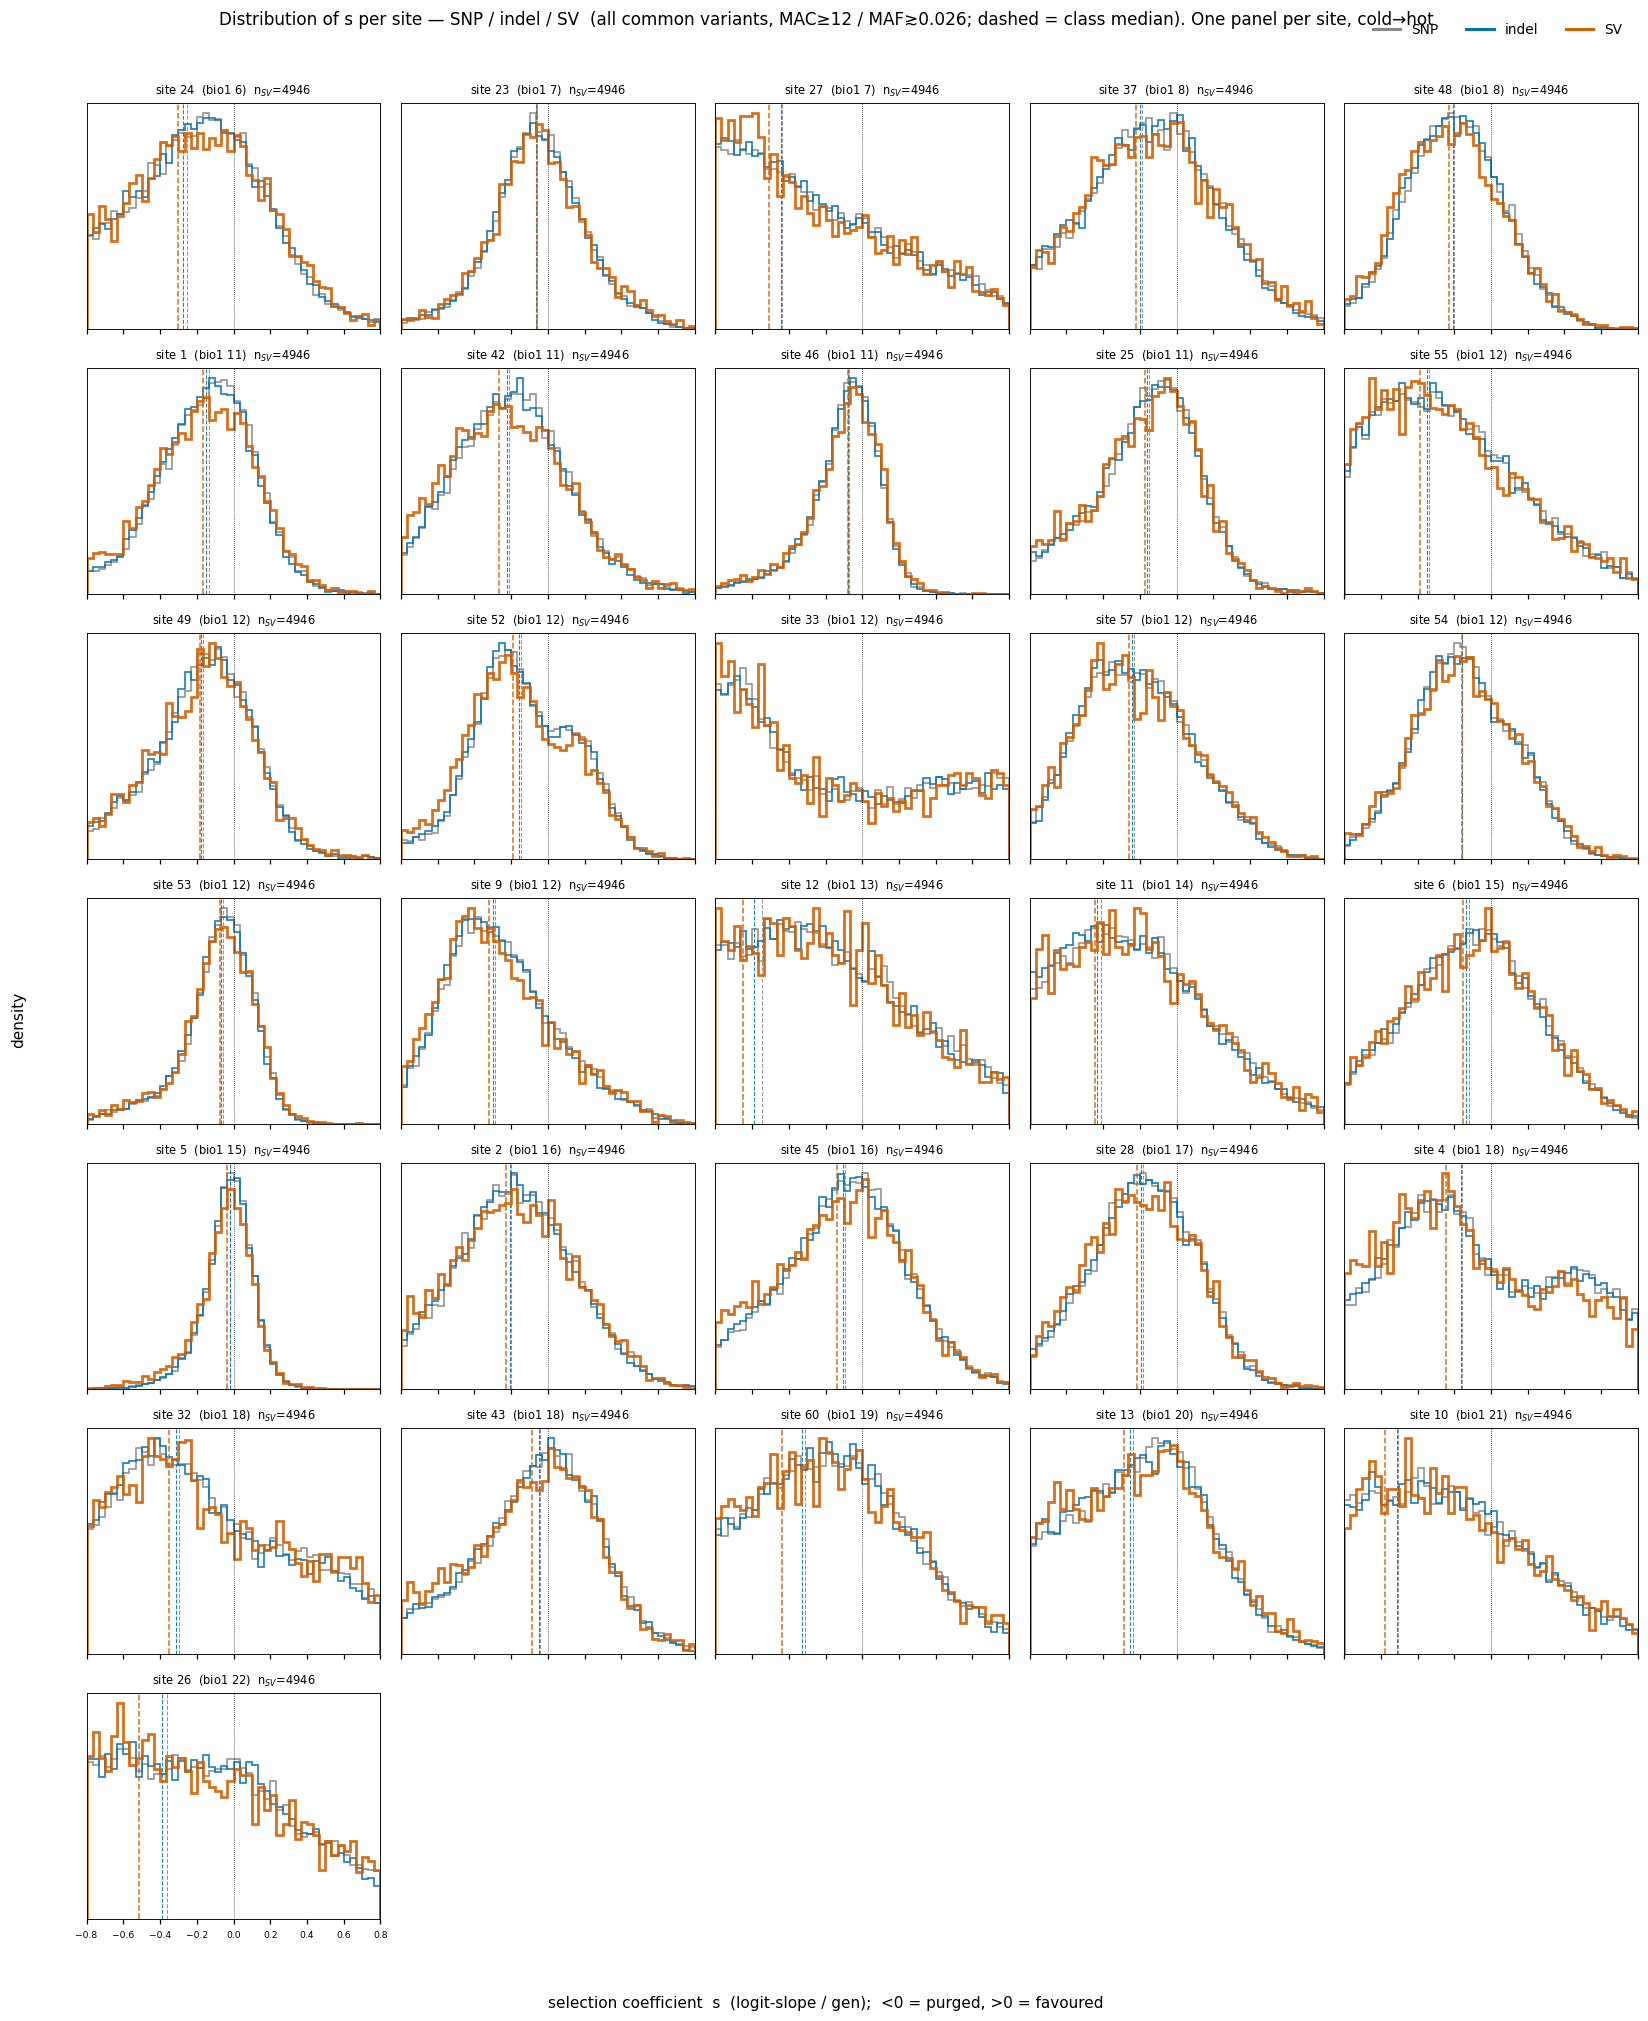

saved s_histogram_by_site.png


In [2]:

sites = meta.site.tolist()
ncol, nrow = 5, int(np.ceil(len(sites)/5))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.6*nrow), sharex=True)
axes = axes.ravel()
for ax in axes[len(sites):]:
    ax.axis("off")
for i, s in enumerate(sites):
    ax = axes[i]
    nsv = 0
    for cls in ["SNP","indel","SV"]:
        v = get(s, cls)
        if v.size == 0: continue
        if cls == "SV": nsv = v.size
        ax.hist(v, bins=BINS, density=True, histtype="step",
                color=COL[cls], lw=1.8 if cls=="SV" else 1.1, alpha=0.9)
        ax.axvline(np.median(v), color=COL[cls], ls="--", lw=1.0 if cls=="SV" else 0.7, alpha=0.9)
    ax.axvline(0, color="k", lw=0.5, ls=":")
    b1 = meta[meta.site==s].bio1.iloc[0]
    ax.set_title(f"site {s}  (bio1 {b1:.0f})  n$_{{SV}}$={nsv}", fontsize=7.5)
    ax.set_xlim(*XR); ax.tick_params(labelsize=6); ax.set_yticks([])
fig.supxlabel("selection coefficient  s  (logit-slope / gen);  <0 = purged, >0 = favoured",
              y=0.005, fontsize=10)
fig.supylabel("density", x=0.006, fontsize=10)
fig.legend(handles=[Line2D([0],[0],color=COL[c],lw=2,label=c) for c in ["SNP","indel","SV"]],
           loc="upper right", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.99,1.004))
fig.suptitle(f"Distribution of s per site — SNP / indel / SV  (all common variants, MAC≥12 / MAF≳0.026; "
             f"dashed = class median). One panel per site, cold→hot", fontsize=11, y=1.004)
fig.tight_layout(rect=[0.02,0.02,1,0.99])
fig.savefig(f"{G}/s_histogram_by_site.png", dpi=130, bbox_inches="tight")
plt.show()
print("saved s_histogram_by_site.png")


In [3]:

# median-s shift (SV and indel) minus SNP, MAF-filtered, per site
rows=[]
for s in meta.site:
    med={c:np.median(get(s,c)) for c in ["SNP","indel","SV"]}
    rows.append(dict(site=s, bio1=meta[meta.site==s].bio1.iloc[0],
                     sv_minus_snp=med["SV"]-med["SNP"], ind_minus_snp=med["indel"]-med["SNP"]))
sh=pd.DataFrame(rows)
from scipy import stats
nneg=int((sh.sv_minus_snp<0).sum())
print(f"median-s(SV) - median-s(SNP), MAF>=0.10:  median across sites {sh.sv_minus_snp.median():+.4f}")
print(f"SV median below SNP at {nneg}/{len(sh)} sites (sign p={stats.binomtest(nneg,len(sh)).pvalue:.3f})")
print(f"indel-SNP median {sh.ind_minus_snp.median():+.4f} (≈0 => indels like SNPs)")


median-s(SV) - median-s(SNP), MAF>=0.10:  median across sites -0.0330
SV median below SNP at 31/31 sites (sign p=0.000)
indel-SNP median -0.0103 (≈0 => indels like SNPs)


### Takeaway
- **SNP and small-indel histograms overlie each other** at every site — same distribution, same
  median. The non-SNP category's bulk (indels) is indistinguishable from SNPs.
- **The SV histogram (orange) is the one to watch**: where it differs it is shifted/skewed toward
  **negative s (left)**, i.e. more purging — most visibly at warm sites — with essentially no matching
  excess on the positive (favoured) side. The SV median line sits at or left of the SNP/indel median.
- With low-MAF variants removed the effect is modest and the SV histogram is coarse (few hundred SVs
  per site). This is the same conclusion as the other analyses, shown as raw distributions: non-SNP
  category ≈ SNPs; a small SV-specific purifying skew (insertion-driven — see the ins/del split).